In [1]:
#Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Cellphone.csv')

In [3]:
df.head()

,Product_id,Price,Sale,weight,resoloution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
0,203,2357,10,135.0,5.2,424,8,1.35,16.0,3.000,13.00,8.0,2610,7.4
1,880,1749,10,125.0,4.0,233,2,1.30,4.0,1.000,3.15,0.0,1700,9.9
2,40,1916,10,110.0,4.7,312,4,1.20,8.0,1.500,13.00,5.0,2000,7.6
3,99,1315,11,118.5,4.0,233,2,1.30,4.0,0.512,3.15,0.0,1400,11.0
4,880,1749,11,125.0,4.0,233,2,1.30,4.0,1.000,3.15,0.0,1700,9.9


In [7]:
df.shape

(161, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Product_id    161 non-null    int64  
 1   Price         161 non-null    int64  
 2   Sale          161 non-null    int64  
 3   weight        161 non-null    float64
 4   resoloution   161 non-null    float64
 5   ppi           161 non-null    int64  
 6   cpu core      161 non-null    int64  
 7   cpu freq      161 non-null    float64
 8   internal mem  161 non-null    float64
 9   ram           161 non-null    float64
 10  RearCam       161 non-null    float64
 11  Front_Cam     161 non-null    float64
 12  battery       161 non-null    int64  
 13  thickness     161 non-null    float64
dtypes: float64(8), int64(6)
memory usage: 17.7 KB


In [8]:
df.describe()

,Product_id,Price,Sale,weight,resoloution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
count,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000
mean,675.559006,2215.596273,621.465839,170.426087,5.209938,335.055901,4.857143,1.502832,24.501714,2.204994,10.378261,4.503106,2842.111801,8.921739
std,410.851583,768.187171,1546.618517,92.888612,1.509953,134.826659,2.444016,0.599783,28.804773,1.609831,6.181585,4.342053,1366.990838,2.192564
min,10.000000,614.000000,10.000000,66.000000,1.400000,121.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,800.000000,5.100000
25%,237.000000,1734.000000,37.000000,134.100000,4.800000,233.000000,4.000000,1.200000,8.000000,1.000000,5.000000,0.000000,2040.000000,7.600000
50%,774.000000,2258.000000,106.000000,153.000000,5.150000,294.000000,4.000000,1.400000,16.000000,2.000000,12.000000,5.000000,2800.000000,8.400000
75%,1026.000000,2744.000000,382.000000,170.000000,5.500000,428.000000,8.000000,1.875000,32.000000,3.000000,16.000000,8.000000,3240.000000,9.800000
max,1339.000000,4361.000000,9807.000000,753.000000,12.200000,806.000000,8.000000,2.700000,128.000000,6.000000,23.000000,20.000000,9500.000000,18.500000


In [9]:
df.isnull().sum()

Product_id      0
Price           0
Sale            0
weight          0
resoloution     0
ppi             0
cpu core        0
cpu freq        0
internal mem    0
ram             0
RearCam         0
Front_Cam       0
battery         0
thickness       0
dtype: int64

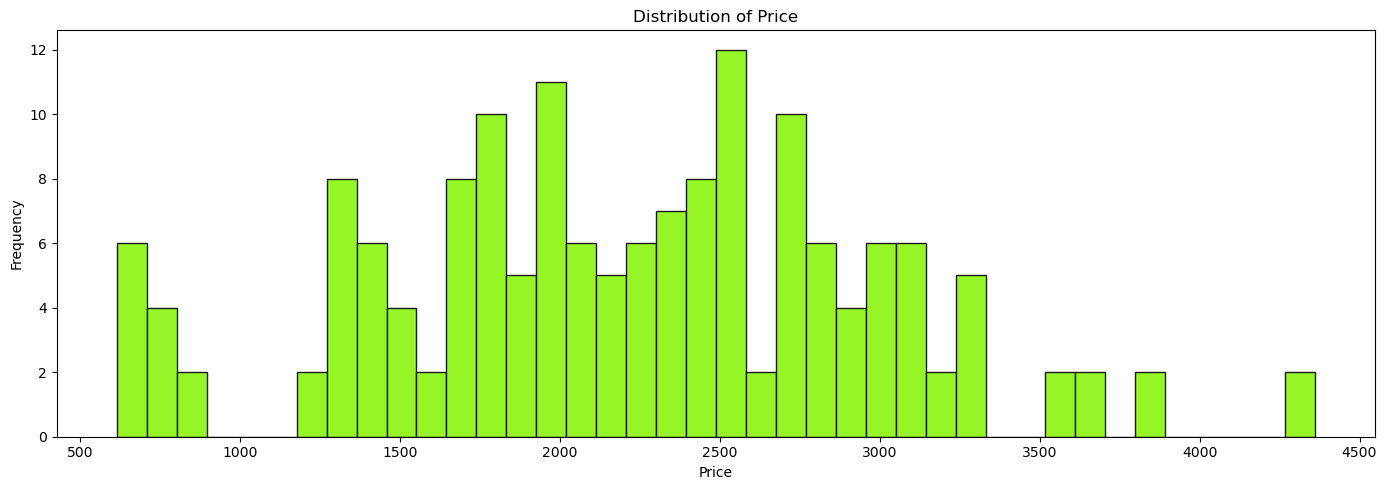

In [29]:
# Target Variable Distribution

target_col = 'Price'

fig, ax = plt.subplots(figsize=(14, 5))

# Histogram
ax.hist(df[target_col],
        bins=40,
        color='#95F527',
        edgecolor='#191C16')

ax.set_title(f'Distribution of {target_col}')
ax.set_xlabel(target_col)
ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()


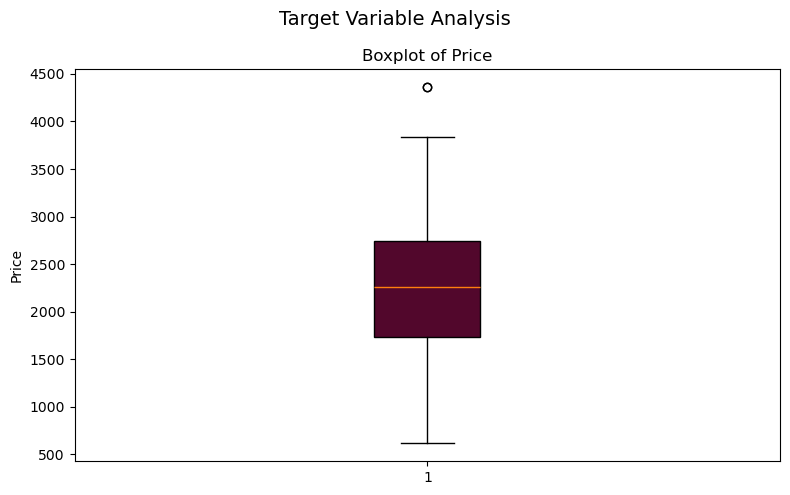

In [24]:
# Boxplot

target_col = 'Price'

fig, ax = plt.subplots(figsize=(8, 5))

ax.boxplot(df[target_col], patch_artist=True,
           boxprops=dict(facecolor='#52072C'))

ax.set_title(f'Boxplot of {target_col}')
ax.set_ylabel(target_col)

plt.suptitle('Target Variable Analysis', fontsize=14)
plt.tight_layout()
plt.show()

In [14]:
print(f"Skewness : {df[target_col].skew():.4f}")
print(f"Kurtosis : {df[target_col].kurt():.4f}")

Skewness : 0.0523
Kurtosis : -0.0563


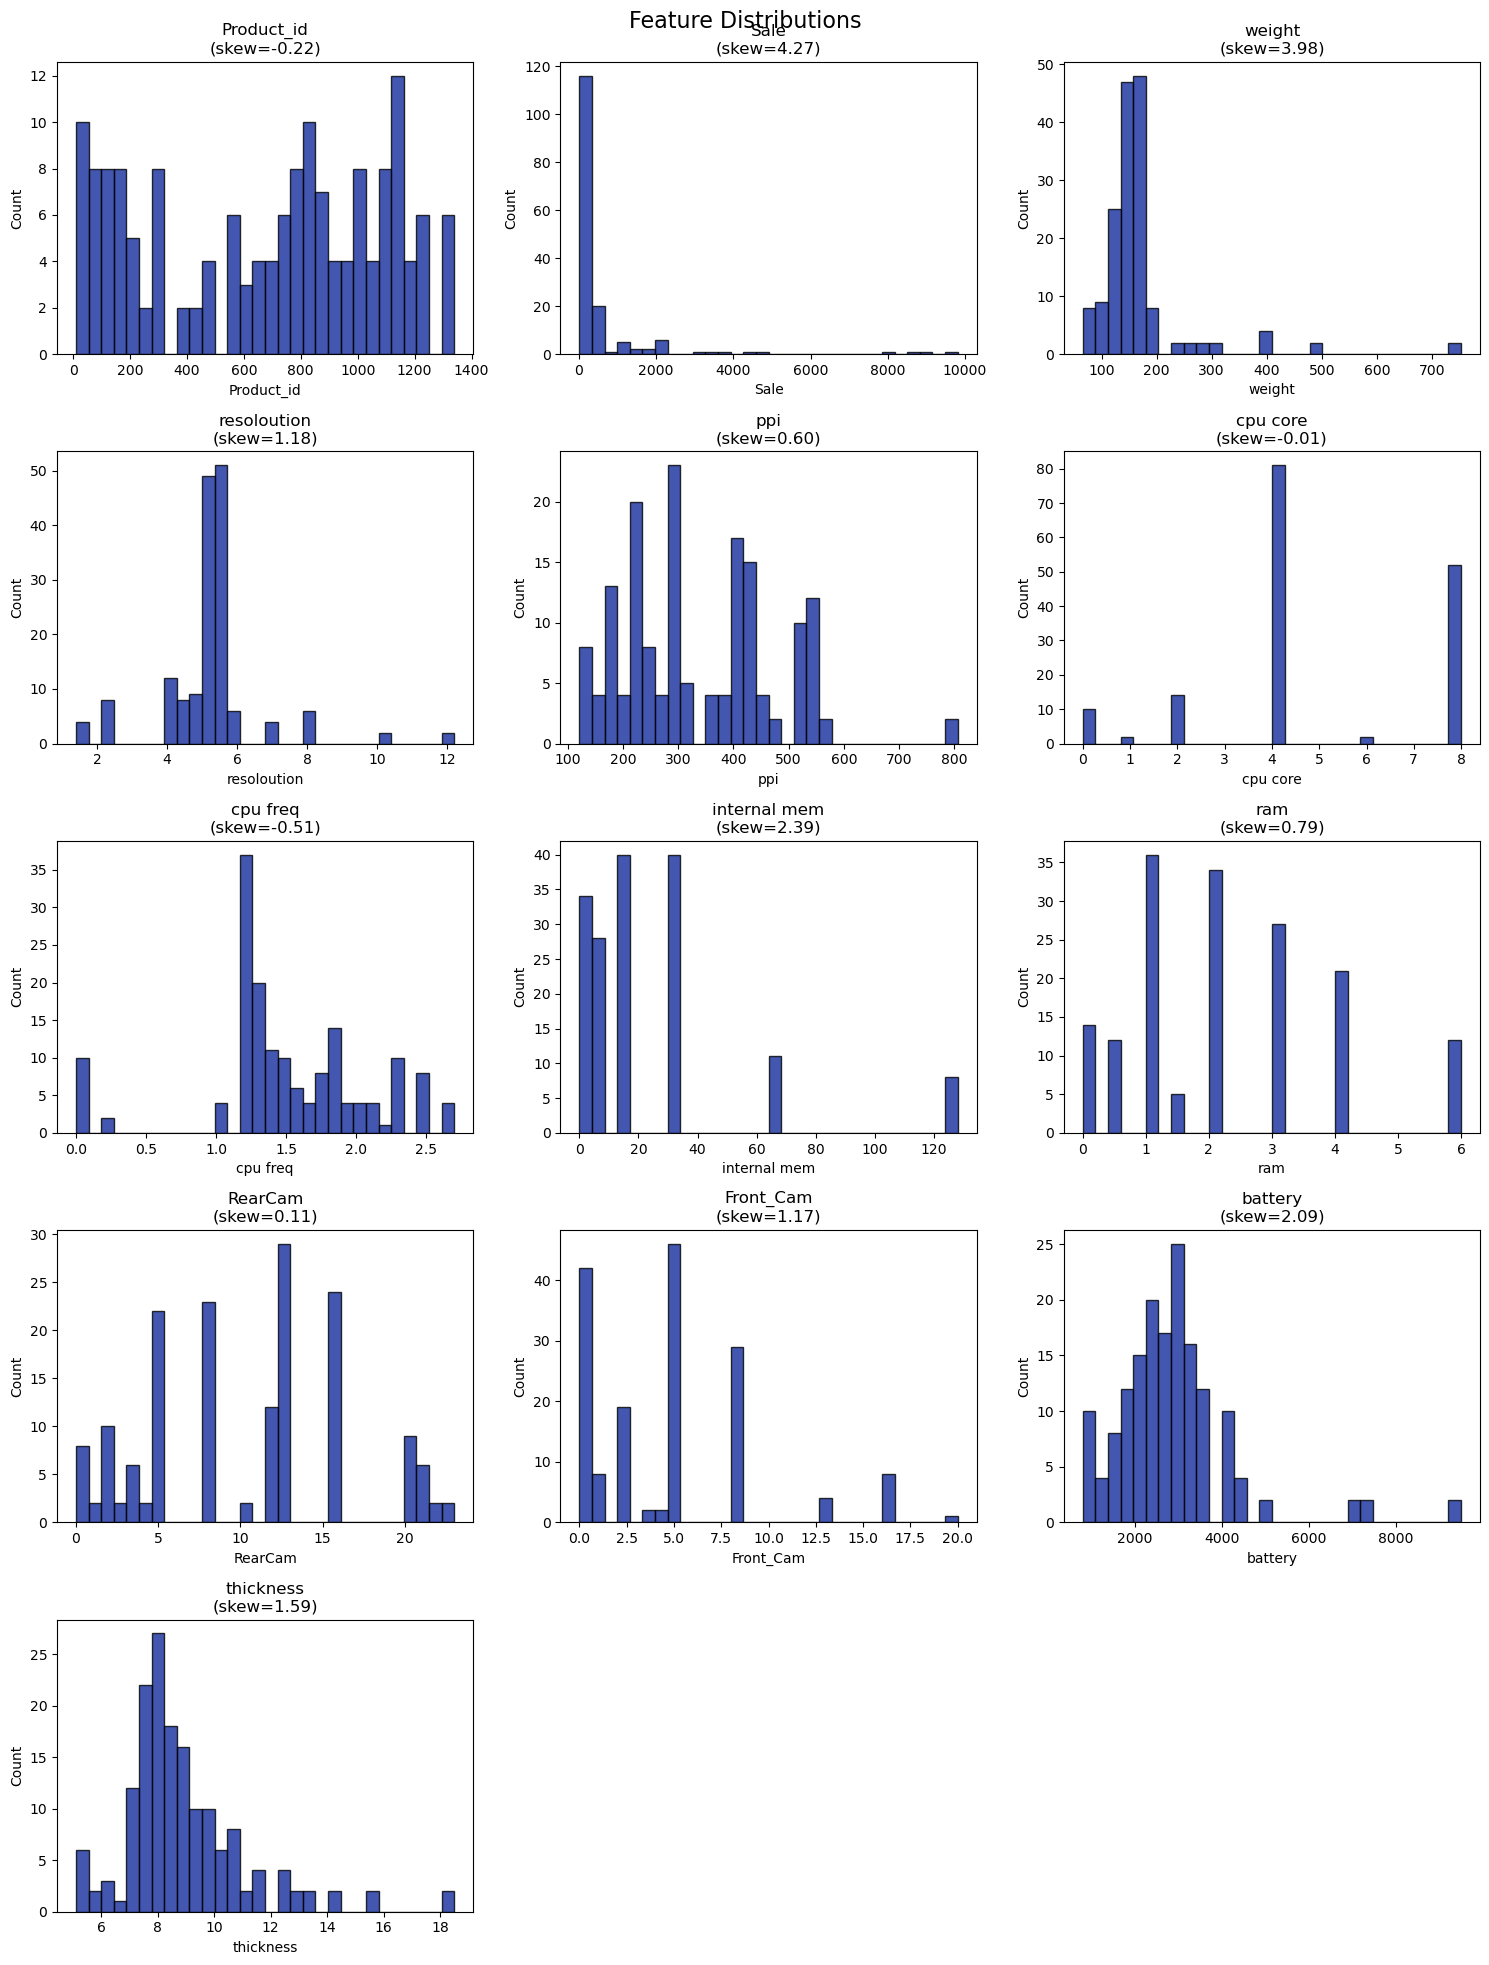

In [32]:
#Feature Distributions

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove(target_col)

n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='#142D9C', edgecolor='black', alpha=0.8)
    axes[i].set_title(f'{col}\n(skew={df[col].skew():.2f})')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions', fontsize=16)
plt.tight_layout()
plt.show()

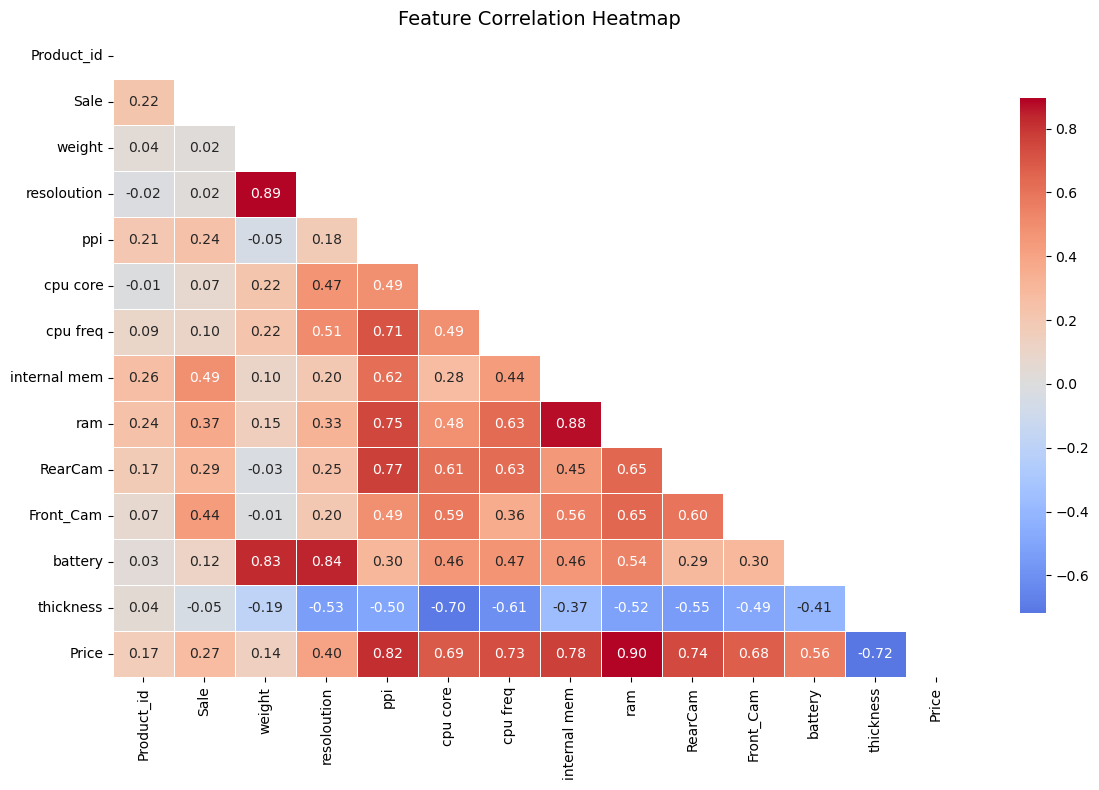

In [35]:
# Correlation Heatmap

plt.figure(figsize=(12, 8))

corr_matrix = df[num_cols + [target_col]].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)

plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

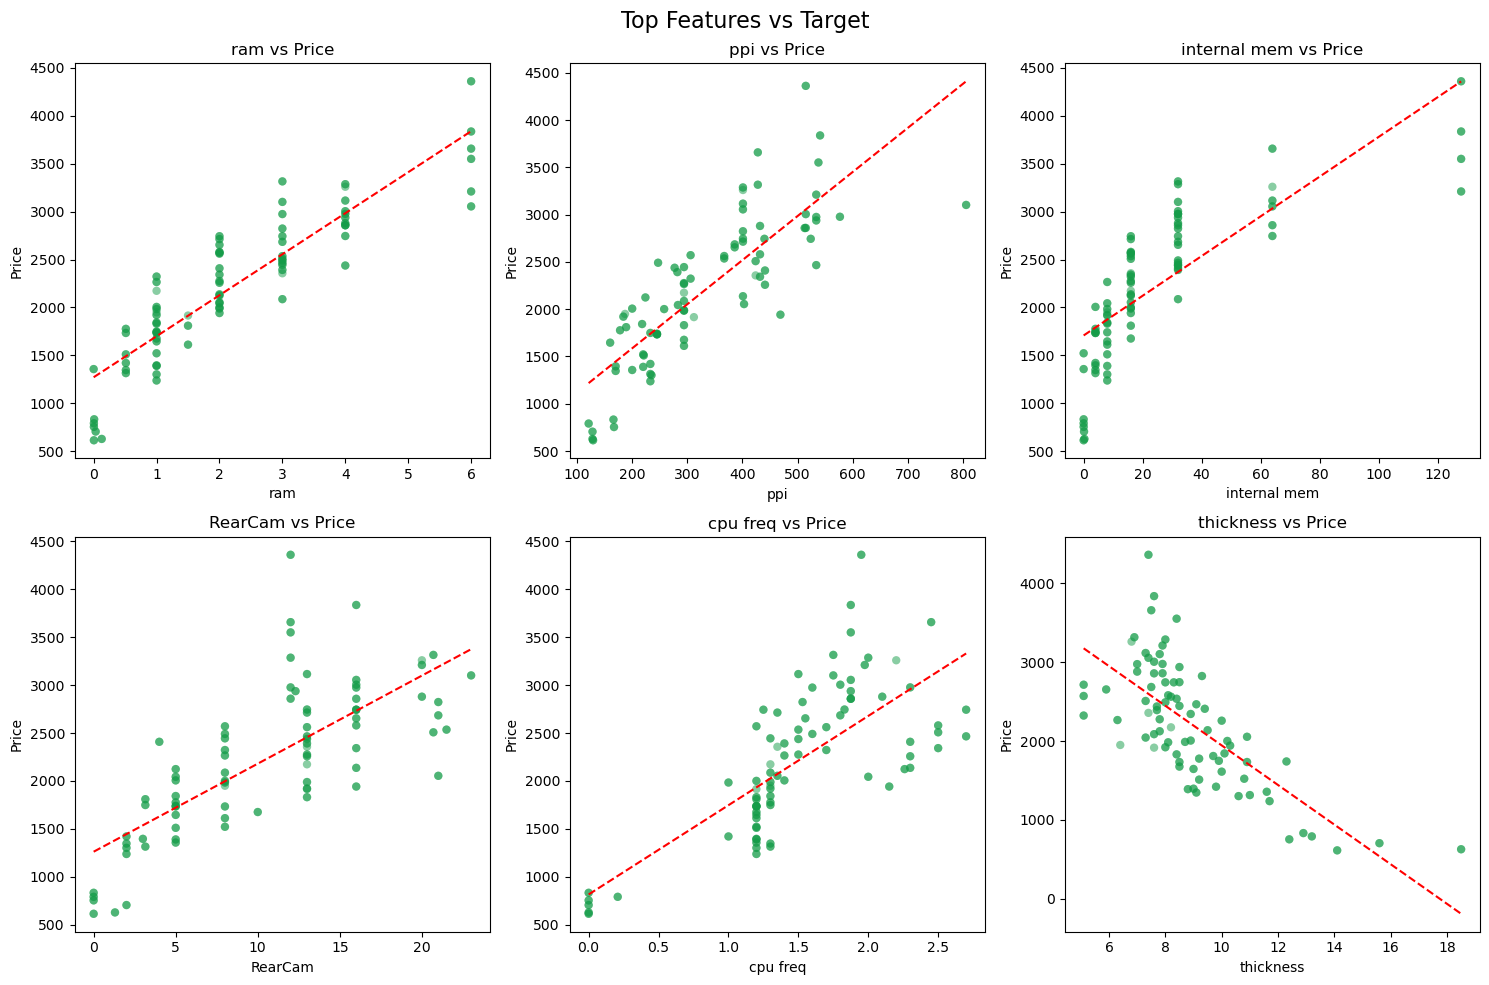

In [37]:
#Scatter Plots — Top Features vs Target


top_features = corr_matrix[target_col].drop(target_col).abs().nlargest(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    axes[i].scatter(df[feat], df[target_col], alpha=0.5,
                    color='#149C48', edgecolor='none')

    
    # Trend line
    z = np.polyfit(df[feat], df[target_col], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    axes[i].plot(x_line, p(x_line), 'r--', linewidth=1.5)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel(target_col)
    axes[i].set_title(f'{feat} vs {target_col}')
    

plt.suptitle('Top Features vs Target', fontsize=16)
plt.tight_layout()
plt.show()

In [77]:
# skewness in the variables and the transformations.

# Skewness Report

skewness = df[num_cols + [target_col]].skew().sort_values(ascending=False)

skewness_df = pd.DataFrame({
    'Skewness': skewness,
    'Level': skewness.apply(lambda x: 
        'High'     if abs(x) > 1   else 
        'Moderate' if abs(x) > 0.5 else 
        'Low')
})

print(skewness_df)

highly_skewed = skewness[abs(skewness) > 1].index.tolist()
print(f"\nHighly skewed columns (skew > 1): {highly_skewed}")

              Skewness     Level
Sale          4.269384      High
weight        3.981756      High
internal mem  2.389683      High
battery       2.092660      High
thickness     1.587680      High
resoloution   1.176110      High
Front_Cam     1.169750      High
ram           0.792698  Moderate
ppi           0.602503  Moderate
RearCam       0.106929       Low
Price         0.052347       Low
cpu core     -0.009077       Low
Product_id   -0.216869       Low
cpu freq     -0.512663  Moderate

Highly skewed columns (skew > 1): ['Sale', 'weight', 'internal mem', 'battery', 'thickness', 'resoloution', 'Front_Cam']


In [40]:
# Apply log1p Transformation to Highly Skewed Features

df_transformed = df.copy()

transformed_cols = []
for col in highly_skewed:
    if df[col].min() >= 0:
        df_transformed[col] = np.log1p(df[col])
        transformed_cols.append(col)
        print(f"log1p applied to '{col}'")
        print(f"   Before skew: {df[col].skew():.3f} → After: {df_transformed[col].skew():.3f}")
    else:
        print(f"Skipping '{col}' — contains negative values")

if not transformed_cols:
    print("No transformations needed.")

log1p applied to 'Sale'
   Before skew: 4.269 → After: 0.615
log1p applied to 'weight'
   Before skew: 3.982 → After: 1.323
log1p applied to 'internal mem'
   Before skew: 2.390 → After: -0.622
log1p applied to 'battery'
   Before skew: 2.093 → After: -0.361
log1p applied to 'thickness'
   Before skew: 1.588 → After: 0.592
log1p applied to 'resoloution'
   Before skew: 1.176 → After: -1.068
log1p applied to 'Front_Cam'
   Before skew: 1.170 → After: -0.317


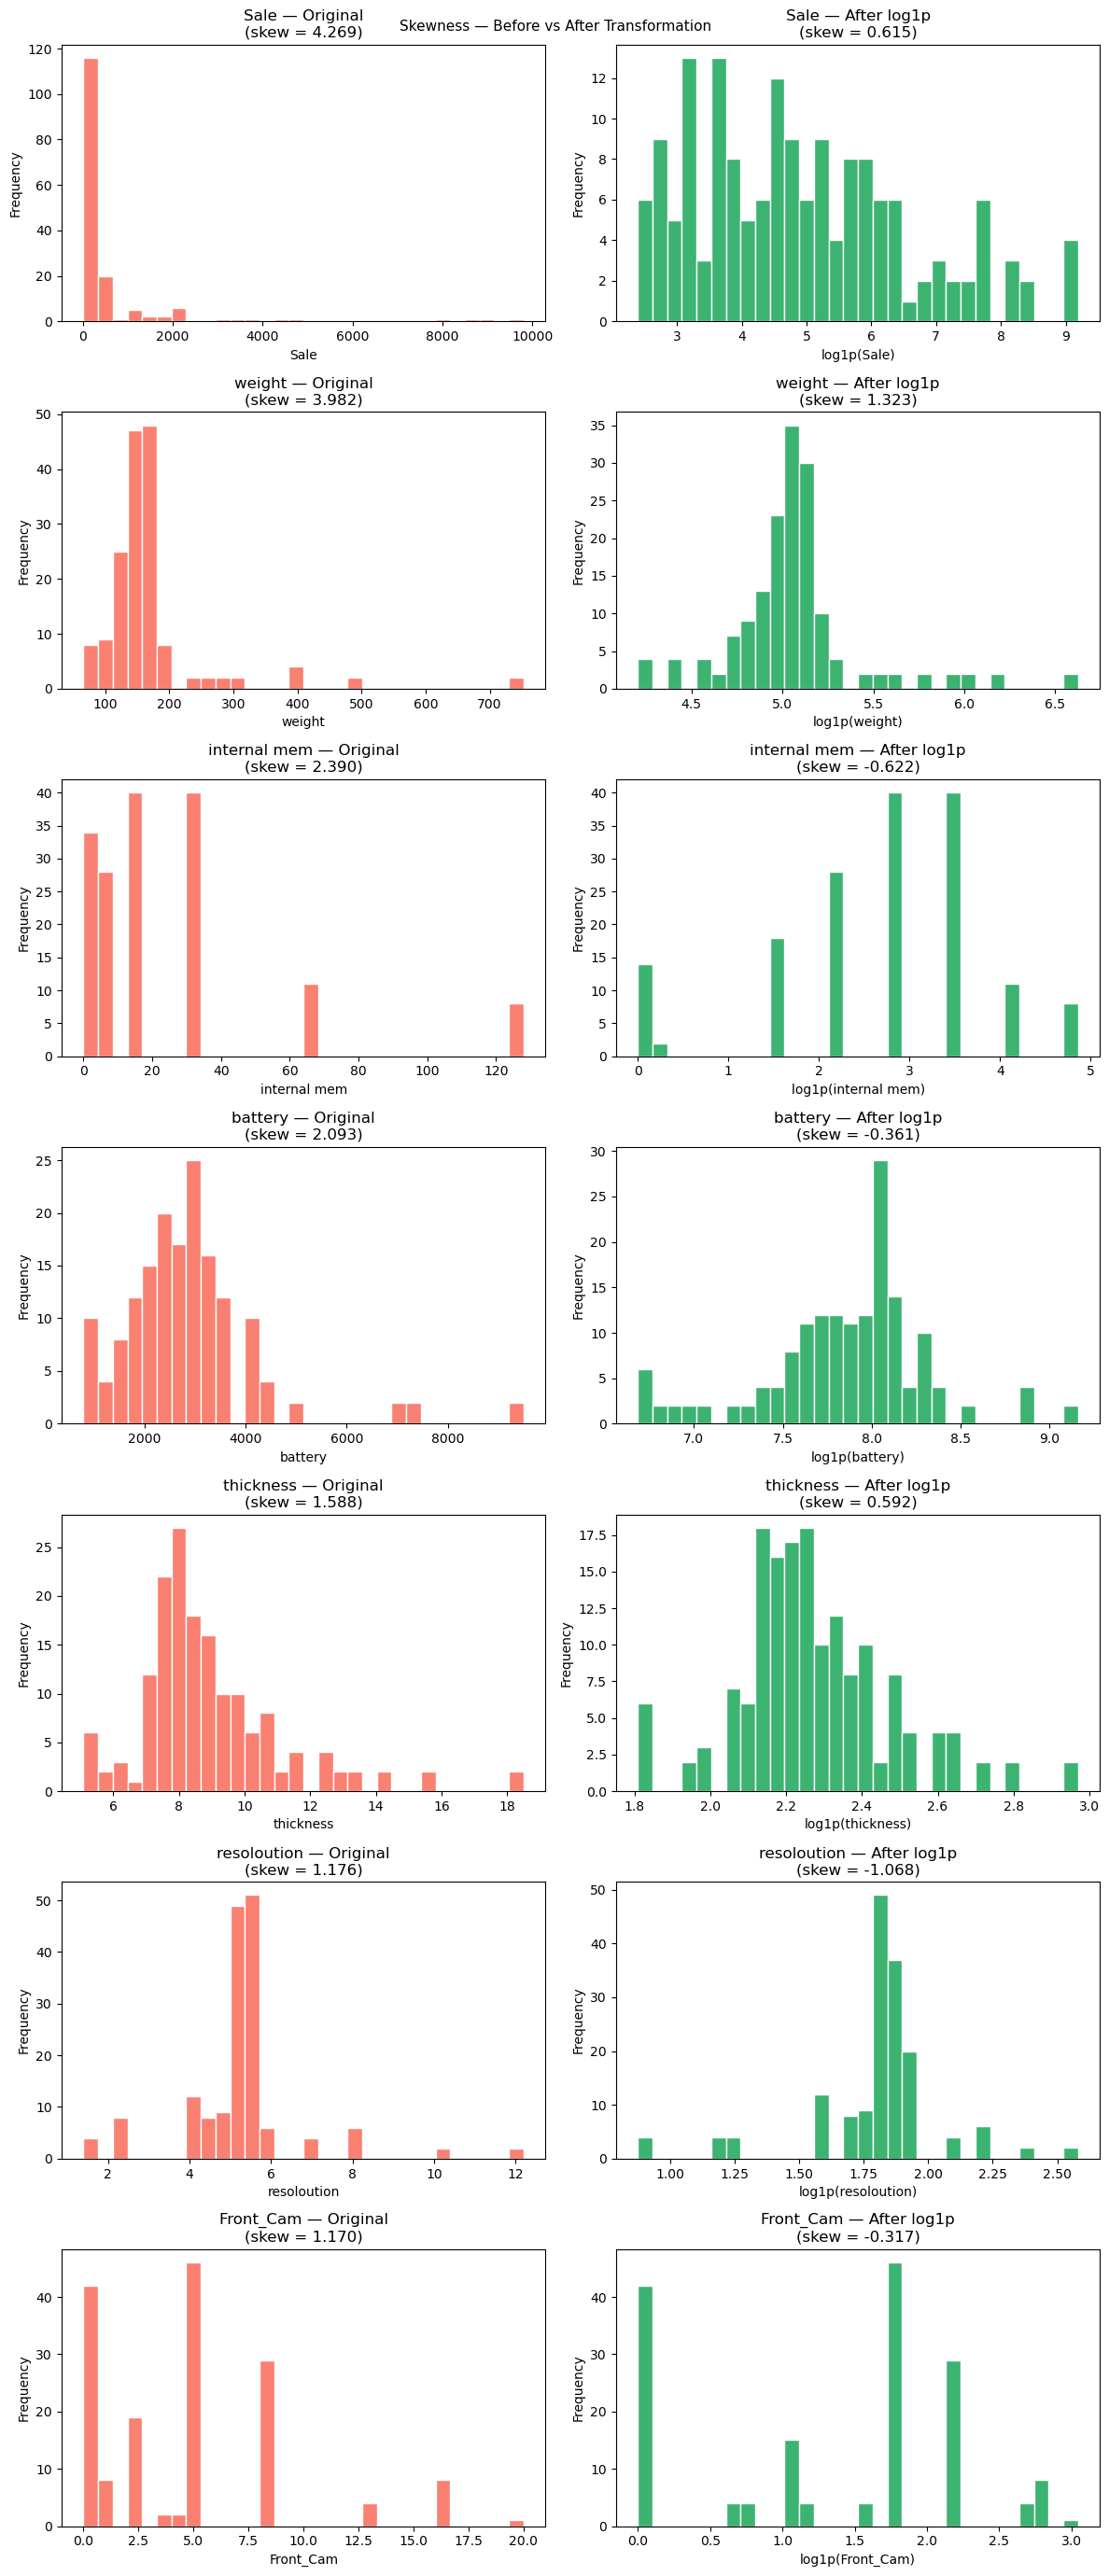

In [78]:
#Before & After Transformation Visualisation


if transformed_cols:
    fig, axes = plt.subplots(len(transformed_cols), 2,
                              figsize=(12, 4 * len(transformed_cols)))
    
    # Handle single row case
    if len(transformed_cols) == 1:
        axes = [axes]

    for i, col in enumerate(transformed_cols):
        # Before
        axes[i][0].hist(df[col], bins=30, color='salmon', edgecolor='white')
        axes[i][0].set_title(f'{col} — Original\n(skew = {df[col].skew():.3f})')
        axes[i][0].set_xlabel(col)
        axes[i][0].set_ylabel('Frequency')

        # After
        axes[i][1].hist(df_transformed[col], bins=30, 
                        color='mediumseagreen', edgecolor='white')
        axes[i][1].set_title(f'{col} — After log1p\n(skew = {df_transformed[col].skew():.3f})')
        axes[i][1].set_xlabel(f'log1p({col})')
        axes[i][1].set_ylabel('Frequency')

    plt.suptitle('Skewness — Before vs After Transformation', fontsize=11)
    plt.tight_layout()
    plt.show()

else:
    print("No transformations were applied — no plots to show.")

In [43]:
# Outlier Detection — IQR Method

def detect_outliers_iqr(df, cols):
    report = []
    for col in cols:
        Q1  = df[col].quantile(0.25)
        Q3  = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
        pct = (n_outliers / len(df)) * 100
        report.append({
            'Column'        : col,
            'Q1'            : round(Q1, 2),
            'Q3'            : round(Q3, 2),
            'Lower Fence'   : round(lower, 2),
            'Upper Fence'   : round(upper, 2),
            'Outlier Count' : n_outliers,
            'Outlier %'     : round(pct, 2)
        })
    return pd.DataFrame(report).sort_values('Outlier Count', ascending=False)

outlier_report = detect_outliers_iqr(df_transformed, num_cols + [target_col])
outlier_report

,Column,Q1,Q3,Lower Fence,Upper Fence,Outlier Count,Outlier %
3,resoloution,1.76,1.87,1.59,2.04,26,16.15
2,weight,4.91,5.14,4.55,5.50,22,13.66
11,battery,7.62,8.08,6.93,8.78,16,9.94
7,internal mem,2.20,3.50,0.25,5.45,16,9.94
6,cpu freq,1.20,1.88,0.19,2.89,10,6.21
12,thickness,2.15,2.38,1.81,2.72,10,6.21
13,Price,1734.00,2744.00,219.00,4259.00,2,1.24
4,ppi,233.00,428.00,-59.50,720.50,2,1.24
0,Product_id,237.00,1026.00,-946.50,2209.50,0,0.00
1,Sale,3.64,5.95,0.17,9.41,0,0.00


In [46]:
#Outlier Treatment — Capping at 1st & 99th Percentile


cols_with_outliers = outlier_report[outlier_report['Outlier Count'] > 0]['Column'].tolist()

df_clean = df_transformed.copy()

if cols_with_outliers:
    for col in cols_with_outliers:
        lower_cap = df_clean[col].quantile(0.01)
        upper_cap = df_clean[col].quantile(0.99)
        df_clean[col] = df_clean[col].clip(lower=lower_cap, upper=upper_cap)
        print(f" '{col}' capped → [{lower_cap:.3f}, {upper_cap:.3f}]")
else:
    print(" No outliers to treat.")

print(f"\nDataset shape after treatment: {df_clean.shape}")

 'resoloution' capped → [0.900, 2.476]
 'weight' capped → [4.238, 6.367]
 'battery' capped → [6.686, 9.009]
 'internal mem' capped → [0.000, 4.860]
 'cpu freq' capped → [0.000, 2.700]
 'thickness' capped → [1.808, 2.874]
 'Price' capped → [622.400, 4046.600]
 'ppi' capped → [125.200, 668.600]

Dataset shape after treatment: (161, 14)


In [48]:
# Feature / Target Split & Train-Test Split

X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

# Handle categorical columns if any
cat_cols = X.select_dtypes(include='object').columns.tolist()
if cat_cols:
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
    print(f"One-hot encoded: {cat_cols}")


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


print(f"Train set : {X_train.shape}")
print(f"Test set  : {X_test.shape}")

Train set : (128, 13)
Test set  : (33, 13)


In [52]:
#Feature Scaling — StandardScaler


scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   
X_test_sc  = scaler.transform(X_test)        


print(f"Train mean ≈ 0 : {X_train_sc.mean(axis=0).mean():.6f}")
print(f"Train std  ≈ 1 : {X_train_sc.std(axis=0).mean():.6f}")

Train mean ≈ 0 : 0.000000
Train std  ≈ 1 : 1.000000


In [75]:
# Evaluate Model Performance

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    
    model.fit(X_tr, y_tr)
    
    y_pred_tr = model.predict(X_tr)
    y_pred_te = model.predict(X_te)

    def get_metrics(y_true, y_pred):
        mae   = mean_absolute_error(y_true, y_pred)
        rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
        r2    = r2_score(y_true, y_pred)
        n, p  = X_tr.shape
        adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
        return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'Adj_R2': adj_r2}

    tr = get_metrics(y_tr, y_pred_tr)
    te = get_metrics(y_te, y_pred_te)

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  {'Metric':<12} {'Train':>10} {'Test':>10}")
    print(f"  {'-'*35}")
    for k in tr:
        print(f"  {k:<12} {tr[k]:>10.4f} {te[k]:>10.4f}")

    return {
        'Model'      : name,
        'Train_MAE'  : tr['MAE'],   'Test_MAE'  : te['MAE'],
        'Train_RMSE' : tr['RMSE'],  'Test_RMSE' : te['RMSE'],
        'Train_R2'   : tr['R2'],    'Test_R2'   : te['R2'],
        'Train_AdjR2': tr['Adj_R2'],'Test_AdjR2': te['Adj_R2'],
        'model_obj'  : model
    }

In [55]:
# Linear Regression

lr = LinearRegression()
res_lr = evaluate_model('Linear Regression', lr,
                         X_train_sc, y_train, X_test_sc, y_test)


  Linear Regression
  Metric            Train       Test
  -----------------------------------
  MAE            133.7185   161.9504
  RMSE           169.9775   187.4859
  R2               0.9503     0.9336
  Adj_R2           0.9446     0.9260


In [56]:
#Ridge Regression (L2) — Cross-Validated Lambda

alphas = np.logspace(-3, 4, 50)

ridge_cv = RidgeCV(alphas=alphas, cv=5, scoring='r2')
ridge_cv.fit(X_train_sc, y_train)
best_alpha_ridge = ridge_cv.alpha_

print(f"Best Ridge alpha (λ): {best_alpha_ridge:.4f}")

ridge = Ridge(alpha=best_alpha_ridge)
res_ridge = evaluate_model(f'Ridge (λ={best_alpha_ridge:.4f})', ridge,
                            X_train_sc, y_train, X_test_sc, y_test)

Best Ridge alpha (λ): 1.9307

  Ridge (λ=1.9307)
  Metric            Train       Test
  -----------------------------------
  MAE            132.5590   159.2799
  RMSE           170.4137   185.8642
  R2               0.9500     0.9348
  Adj_R2           0.9443     0.9273


In [60]:
# Lasso Regression (L1)

lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000)
lasso_cv.fit(X_train_sc, y_train)
best_alpha_lasso = lasso_cv.alpha_

print(f"Best Lasso alpha : {best_alpha_lasso:.4f}")

lasso = Lasso(alpha=best_alpha_lasso, max_iter=10000)
res_lasso = evaluate_model(f'Lasso ({best_alpha_lasso:.4f})', lasso,
                            X_train_sc, y_train, X_test_sc, y_test)

# Show feature selection effect
lasso_coefs = pd.Series(lasso.coef_, index=X.columns)
n_selected  = (lasso_coefs != 0).sum()

Best Lasso alpha : 3.7276

  Lasso (3.7276)
  Metric            Train       Test
  -----------------------------------
  MAE            133.0351   155.5966
  RMSE           171.9806   183.2280
  R2               0.9491     0.9366
  Adj_R2           0.9433     0.9294


In [62]:
# ElasticNet Regression (L1 + L2)

l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0]

enet_cv = ElasticNetCV(l1_ratio=l1_ratios, alphas=alphas, cv=5, max_iter=10000)
enet_cv.fit(X_train_sc, y_train)
best_alpha_enet = enet_cv.alpha_
best_l1_ratio   = enet_cv.l1_ratio_

print(f"Best ElasticNet alpha : {best_alpha_enet:.4f}")
print(f"Best l1_ratio         : {best_l1_ratio:.2f}")

enet = ElasticNet(alpha=best_alpha_enet, l1_ratio=best_l1_ratio, max_iter=10000)
res_enet = evaluate_model(f'ElasticNet ({best_alpha_enet:.4f}, l1={best_l1_ratio:.2f})',
                           enet, X_train_sc, y_train, X_test_sc, y_test)

Best ElasticNet alpha : 3.7276
Best l1_ratio         : 1.00

  ElasticNet (3.7276, l1=1.00)
  Metric            Train       Test
  -----------------------------------
  MAE            133.0351   155.5966
  RMSE           171.9806   183.2280
  R2               0.9491     0.9366
  Adj_R2           0.9433     0.9294


In [63]:
# Collect All Results

results = [res_lr, res_ridge, res_lasso, res_enet]
print("All models trained successfully.")

All models trained successfully.


In [64]:
# Overfitting Detection - Train vs Test R² Gap

print(f"{'Model':<40} {'Train R²':>10} {'Test R²':>10} {'Gap':>8} {'Status':>12}")
print("-" * 85)

for r in results:
    gap    = r['Train_R2'] - r['Test_R2']
    status = 'Overfit' if gap > 0.10 else 'OK'
    print(f"{r['Model']:<40} {r['Train_R2']:>10.4f} {r['Test_R2']:>10.4f} {gap:>8.4f} {status:>12}")

Model                                      Train R²    Test R²      Gap       Status
-------------------------------------------------------------------------------------
Linear Regression                            0.9503     0.9336   0.0167           OK
Ridge (λ=1.9307)                             0.9500     0.9348   0.0153           OK
Lasso (3.7276)                               0.9491     0.9366   0.0125           OK
ElasticNet (3.7276, l1=1.00)                 0.9491     0.9366   0.0125           OK


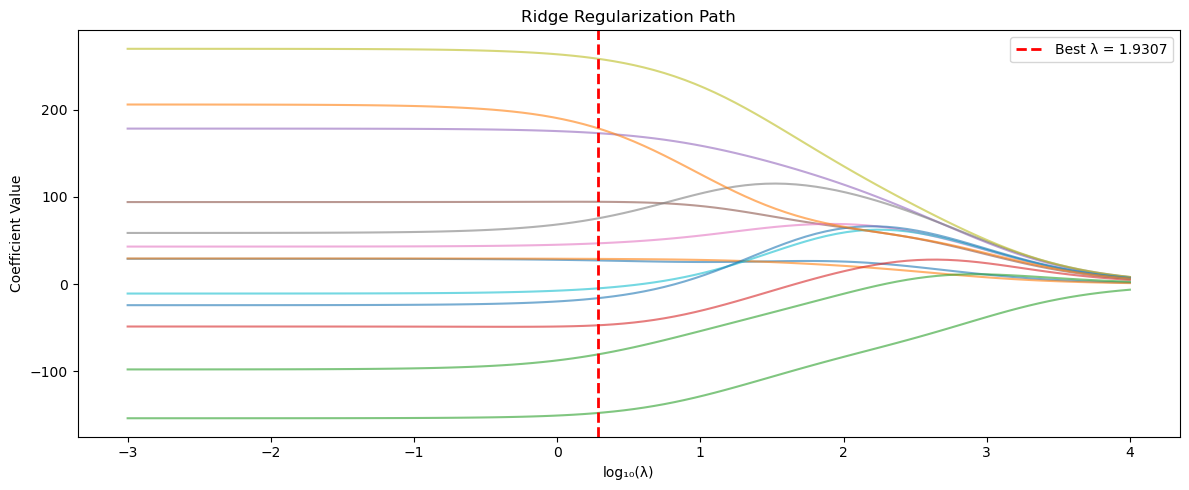

In [67]:
# Ridge Regularization Path

alphas_path = np.logspace(-3, 4, 100)
coefs_path  = []

for a in alphas_path:
    r = Ridge(alpha=a)
    r.fit(X_train_sc, y_train)
    coefs_path.append(r.coef_)

coefs_path = np.array(coefs_path)

plt.figure(figsize=(12, 5))
for i in range(coefs_path.shape[1]):
    plt.plot(np.log10(alphas_path), coefs_path[:, i], alpha=0.6)

plt.axvline(np.log10(best_alpha_ridge), color='red', linestyle='--', linewidth=2,
            label=f'Best λ = {best_alpha_ridge:.4f}')
plt.xlabel('log₁₀(λ)')
plt.ylabel('Coefficient Value')
plt.title('Ridge Regularization Path')
plt.legend()
plt.tight_layout()
plt.show()

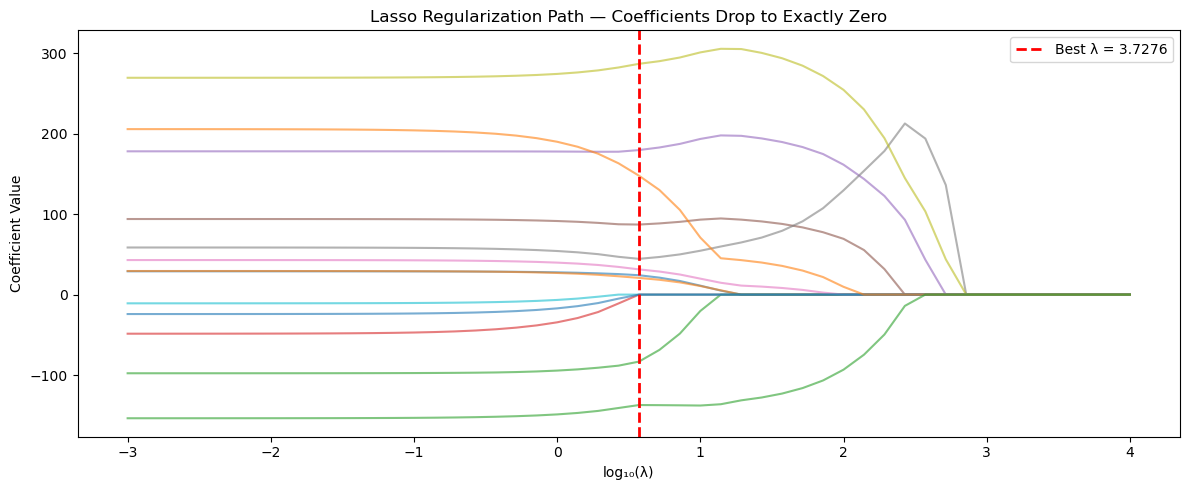

In [68]:
# Lasso Regularization Path

from sklearn.linear_model import lasso_path

alphas_lasso_path, coefs_lasso_path, _ = lasso_path(
    X_train_sc, y_train, alphas=alphas[::-1]
)

plt.figure(figsize=(12, 5))
for i in range(coefs_lasso_path.shape[0]):
    plt.plot(np.log10(alphas_lasso_path), coefs_lasso_path[i, :], alpha=0.6)

plt.axvline(np.log10(best_alpha_lasso), color='red', linestyle='--', linewidth=2,
            label=f'Best λ = {best_alpha_lasso:.4f}')
plt.xlabel('log₁₀(λ)')
plt.ylabel('Coefficient Value')
plt.title('Lasso Regularization Path — Coefficients Drop to Exactly Zero')
plt.legend()
plt.tight_layout()
plt.show()

In [69]:
# Cross-Validation Score — All Models
models_cv = {
    'Linear Regression' : LinearRegression(),
    'Ridge'             : Ridge(alpha=best_alpha_ridge),
    'Lasso'             : Lasso(alpha=best_alpha_lasso, max_iter=10000),
    'ElasticNet'        : ElasticNet(alpha=best_alpha_enet, 
                                     l1_ratio=best_l1_ratio, max_iter=10000)
}

print(f"{'Model':<25} {'CV Mean R²':>12} {'CV Std':>10}")
print("-" * 50)

for name, model in models_cv.items():
    cv_scores = cross_val_score(model, X_train_sc, y_train, cv=5, scoring='r2')
    print(f"{name:<25} {cv_scores.mean():>12.4f} {cv_scores.std():>10.4f}")

Model                       CV Mean R²     CV Std
--------------------------------------------------
Linear Regression               0.9307     0.0261
Ridge                           0.9315     0.0270
Lasso                           0.9320     0.0276
ElasticNet                      0.9320     0.0276


In [70]:
# Summary Performance Table

summary = pd.DataFrame([{
    'Model'       : r['Model'],
    'Train MAE'   : round(r['Train_MAE'],   4),
    'Test MAE'    : round(r['Test_MAE'],    4),
    'Train RMSE'  : round(r['Train_RMSE'],  4),
    'Test RMSE'   : round(r['Test_RMSE'],   4),
    'Train R²'    : round(r['Train_R2'],    4),
    'Test R²'     : round(r['Test_R2'],     4),
    'Train Adj-R²': round(r['Train_AdjR2'], 4),
    'Test Adj-R²' : round(r['Test_AdjR2'],  4),
} for r in results])

summary.set_index('Model', inplace=True)
summary

,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R²,Test R²,Train Adj-R²,Test Adj-R²
Model,,,,,,,,
Linear Regression,133.7185,161.9504,169.9775,187.4859,0.9503,0.9336,0.9446,0.9260
Ridge (λ=1.9307),132.5590,159.2799,170.4137,185.8642,0.9500,0.9348,0.9443,0.9273
Lasso (3.7276),133.0351,155.5966,171.9806,183.2280,0.9491,0.9366,0.9433,0.9294
"ElasticNet (3.7276, l1=1.00)",133.0351,155.5966,171.9806,183.2280,0.9491,0.9366,0.9433,0.9294


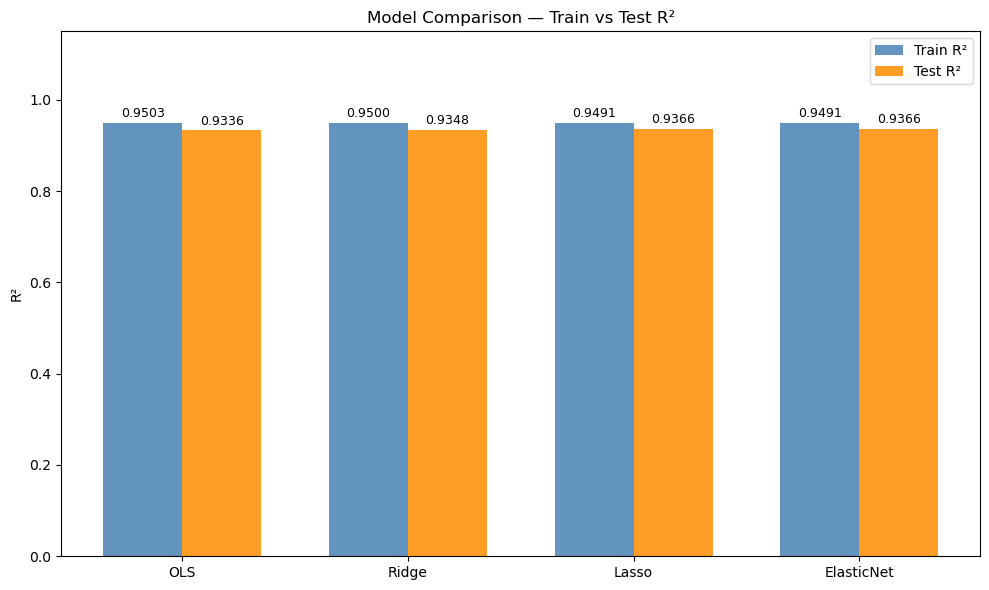

In [71]:
# Bar Chart — Train vs Test R²

model_names = ['OLS', 'Ridge', 'Lasso', 'ElasticNet']
train_r2    = [r['Train_R2'] for r in results]
test_r2     = [r['Test_R2']  for r in results]

x     = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, train_r2, width, label='Train R²',
               color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, test_r2,  width, label='Test R²',
               color='darkorange', alpha=0.85)

ax.set_ylabel('R²')
ax.set_title('Model Comparison — Train vs Test R²')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylim(0, 1.15)
ax.legend()

for bar in bars1:
    ax.annotate(f'{bar.get_height():.4f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points',
                ha='center', fontsize=9)
for bar in bars2:
    ax.annotate(f'{bar.get_height():.4f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points',
                ha='center', fontsize=9)

plt.tight_layout()
plt.show()

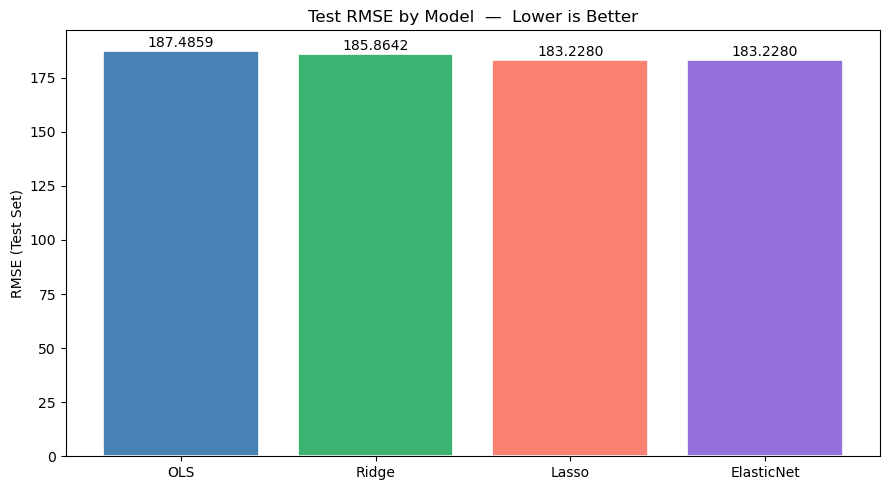

In [72]:
# Bar Chart — Test RMSE Comparison

test_rmse = [r['Test_RMSE'] for r in results]
colors    = ['steelblue', 'mediumseagreen', 'salmon', 'mediumpurple']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(model_names, test_rmse, color=colors, edgecolor='white', linewidth=1.2)

ax.set_ylabel('RMSE (Test Set)')
ax.set_title('Test RMSE by Model  —  Lower is Better')

for bar, val in zip(bars, test_rmse):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.002 * max(test_rmse),
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

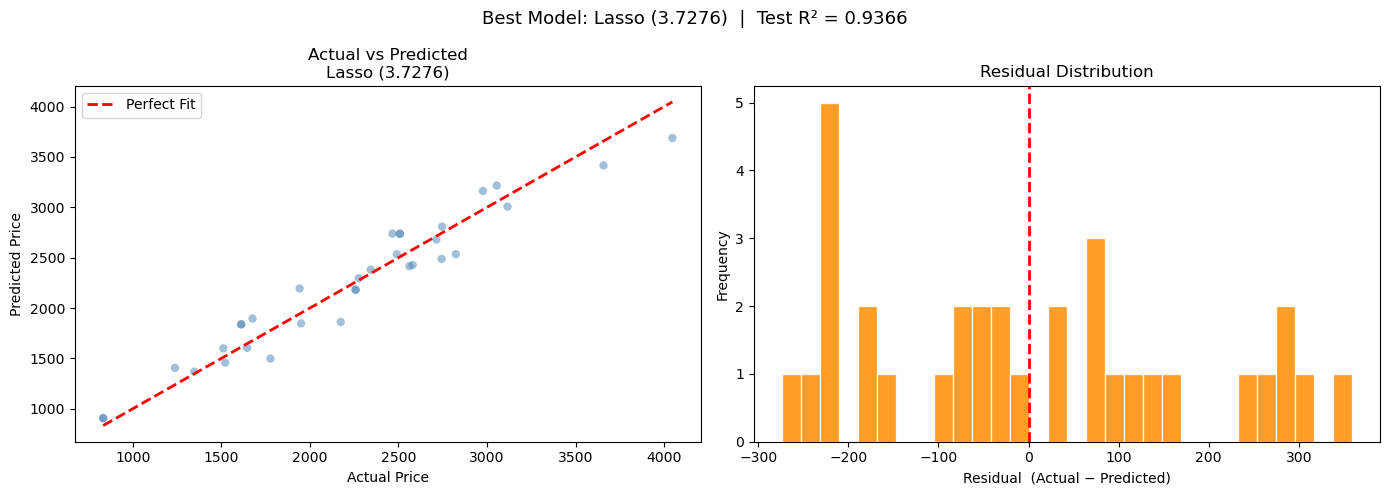

In [73]:
# Actual vs Predicted — Best Model

best_result = max(results, key=lambda r: r['Test_R2'])
best_model  = best_result['model_obj']
y_pred_best = best_model.predict(X_test_sc)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted scatter
axes[0].scatter(y_test, y_pred_best, alpha=0.5, color='steelblue', edgecolor='none')
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Fit')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title(f'Actual vs Predicted\n{best_result["Model"]}')
axes[0].legend()

# Residuals distribution
residuals = y_test.values - y_pred_best
axes[1].hist(residuals, bins=30, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Residual  (Actual − Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')

plt.suptitle(f'Best Model: {best_result["Model"]}  |  Test R² = {best_result["Test_R2"]:.4f}',
             fontsize=13)
plt.tight_layout()
plt.show()

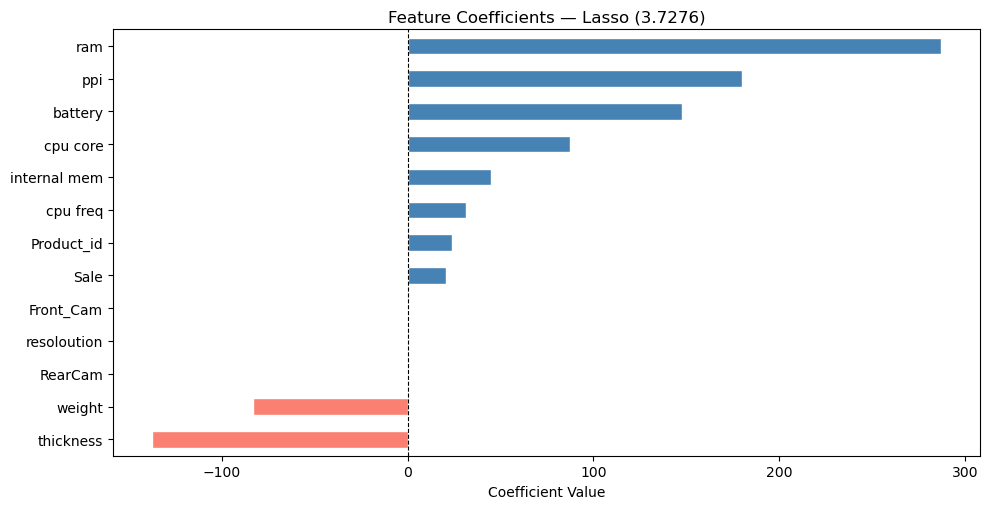


Top 5 most impactful features:
ram          286.795916
ppi          179.836943
battery      147.879384
thickness    137.267953
cpu core      87.156909
dtype: float64


In [74]:
# Feature Coefficients — Best Model

coef_series = pd.Series(best_model.coef_, index=X.columns).sort_values()
colors      = ['salmon' if c < 0 else 'steelblue' for c in coef_series]

plt.figure(figsize=(10, max(5, len(coef_series) * 0.4)))
coef_series.plot(kind='barh', color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title(f'Feature Coefficients — {best_result["Model"]}')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

print("\nTop 5 most impactful features:")
print(coef_series.abs().sort_values(ascending=False).head())